In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import zipfile

zip_path = '/content/drive/MyDrive/Yelp-Photos.zip'
extract_path = '/content/yelp_photos'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping completed.")


Unzipping completed.


In [4]:
import os

for item in os.listdir(extract_path):
    print(item)


__MACOSX
Yelp Photos


In [5]:
yelp_photos_path = '/content/yelp_photos/Yelp Photos'

for item in os.listdir(yelp_photos_path):
    print(item)


yelp_photos.tar
Yelp Dataset Documentation & ToS.pdf


In [6]:
import tarfile

tar_path = '/content/yelp_photos/Yelp Photos/yelp_photos.tar'
extract_images_path = '/content/yelp_images'

with tarfile.open(tar_path, 'r') as tar_ref:
    tar_ref.extractall(extract_images_path)

print("Image extraction completed.")


Image extraction completed.


In [7]:
import os

image_files = os.listdir(extract_images_path)
print("Total images found:", len(image_files))
print("First 10 image file names:", image_files[:10])


Total images found: 3
First 10 image file names: ['Dataset_User_Agreement.pdf', 'photos', 'photos.json']


In [8]:

photos_folder = '/content/yelp_images/photos'
image_files = os.listdir(photos_folder)
print("Total image files:", len(image_files))
print("Sample image files:", image_files[:10])


Total image files: 200098
Sample image files: ['aUGOT5WQgAdmgqgEmdYjrQ.jpg', 'xLCMqs787DD7Mrj-8fKkLA.jpg', 'QTpTnZSpVx8h1HN7U7xCzQ.jpg', 'v1AaTBcp8a0rbP955_1bBQ.jpg', 'vyz6oG7AhlZQUoEjf4MTGQ.jpg', 'aO4n3Ww4qVZvA46cyg_R-w.jpg', 'cJ-HDUy3dHlDcZ-ncwbgfQ.jpg', 'GSvWeMceLmK4tv1gZZIrZw.jpg', 'yqatyz45AnDdkfFi3678WA.jpg', '1x031zLym0LSBvBi3ILBkA.jpg']


In [9]:
import pandas as pd


json_path = '/content/yelp_images/photos.json'
df = pd.read_json(json_path, lines=True)


print("Unique labels:", df['label'].unique())
print(df['label'].value_counts())



Unique labels: ['inside' 'outside' 'drink' 'food' 'menu']
label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64


In [10]:

selected_labels = ['food', 'drink', 'menu', 'inside']
subset_df = df[df['label'].isin(selected_labels)]


balanced_df = subset_df.groupby('label').apply(lambda x: x.sample(n=500, random_state=42)).reset_index(drop=True)

print("Total images selected:", len(balanced_df))
balanced_df.head()


Total images selected: 2000


<ipython-input-10-681f89cf73f7>:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = subset_df.groupby('label').apply(lambda x: x.sample(n=500, random_state=42)).reset_index(drop=True)


,photo_id,business_id,caption,label
0,Chro0cjWAFLtdv-pmGSB6Q,oBNrLz4EDhiscSlbOl8uAw,Bacon Infused Bloody Mary,drink
1,BD8F_GP5TiNCiajFVPqZOA,SV04xdj87VOEa4GJ2dZm_g,,drink
2,Wo16TBTZHfapyV2n_KbCTQ,EM0jUQn-SEnttG8hf-Eq6A,Huckleberry lemon drop at the bar,drink
3,1gBfJMbZtrgcqqvgDaYWYA,5Z_KrsEQsPE0ibKwhYn3ZQ,,drink
4,Qy65xh-hrmPTb2k_-6uZnA,yd5CI-2fASWsrA92dUR1ZA,,drink


In [11]:
import numpy as np
import cv2
from tqdm import tqdm


image_dir = '/content/yelp_images/photos'


IMG_SIZE = 64

X = []
y = []


for idx, row in tqdm(balanced_df.iterrows(), total=balanced_df.shape[0]):
    img_id = row['photo_id']
    label = row['label']
    img_path = os.path.join(image_dir, img_id + '.jpg')


    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        X.append(img.flatten())
        y.append(label)
    except:
        continue

X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)


100%|██████████| 2000/2000 [00:11<00:00, 179.20it/s]


X shape: (1999, 12288)
y shape: (1999,)


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 1599
Test size: 400


In [13]:
from sklearn.svm import SVC


svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

print("SVM training completed.")


SVM training completed.


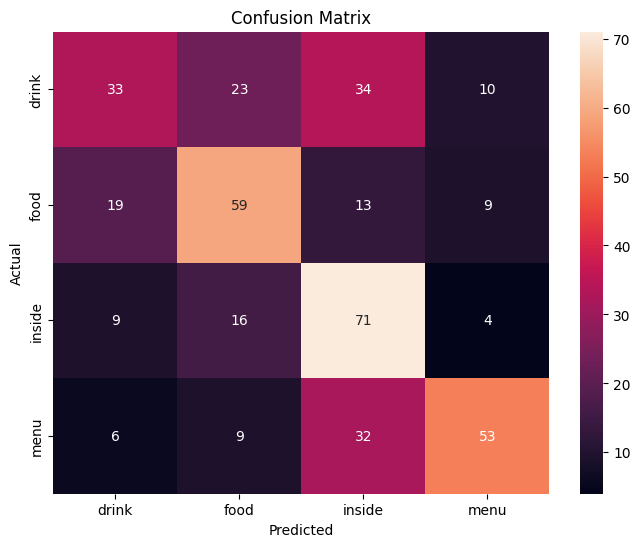

Classification Report:
              precision    recall  f1-score   support

       drink       0.49      0.33      0.40       100
        food       0.55      0.59      0.57       100
      inside       0.47      0.71      0.57       100
        menu       0.70      0.53      0.60       100

    accuracy                           0.54       400
   macro avg       0.55      0.54      0.53       400
weighted avg       0.55      0.54      0.53       400



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = svm_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


In [15]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize


y_prob = svm_model.predict_proba(X_test)


y_test_bin = label_binarize(y_test, classes=np.unique(y_test))


auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
print("Macro-Averaged AUC Score:", round(auc, 4))


Macro-Averaged AUC Score: 0.7986
